<a href="https://colab.research.google.com/github/yaryna-tsiuk/global-sales-analysis-python/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/data
import pandas as pd

countries = pd.read_csv("countries.csv")
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
print(countries.head())
print(events.head())
print(products.head())

Mounted at /content/drive
/content/drive/MyDrive/data
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1    

In [ ]:
print(countries.columns)
print(events.columns)
print(products.columns)

Index(['name', 'alpha-2', 'alpha-3', 'region', 'sub-region'], dtype='object')
Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code',
       'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost'],
      dtype='object')
Index(['id', 'item_type'], dtype='object')


In [ ]:
print(countries.shape)
print(events.shape)
print(products.shape)

(249, 5)
(1330, 10)
(12, 2)


In [ ]:
print(countries.dtypes)
print(events.dtypes)
print(products.dtypes)

name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object
id            int64
item_type    object
dtype: object


In [ ]:
print(countries.describe())
print(events.describe())
print(products.describe())

               name alpha-2 alpha-3  region          sub-region
count           249     248     249     248                 248
unique          249     248     249       5                  17
top     Afghanistan      AF     AFG  Africa  Sub-Saharan Africa
freq              1       1       1      60                  53
           Order ID   Product ID   Units Sold   Unit Price    Unit Cost
count  1.330000e+03  1330.000000  1328.000000  1330.000000  1330.000000
mean   5.412048e+08  5788.096241  4952.201807   264.893541   187.246812
std    2.573882e+08  2820.728878  2905.198996   217.323460   176.158873
min    1.006406e+08  1270.000000     2.000000     9.330000     6.920000
25%    3.190004e+08  3127.000000  2356.750000    81.730000    35.840000
50%    5.387164e+08  5988.000000  4962.000000   154.060000    97.440000
75%    7.544628e+08  8681.000000  7459.500000   437.200000   263.330000
max    9.998797e+08  8969.000000  9999.000000   668.270000   524.960000
                id
count    12.0

The `countries` table contains the following columns:
* `name` — country name
* `alpha-2` — two-letter country code
* `alpha-3` — three-letter country code and key field for joins
* `region` — region
* `sub-region` — sub-region

The `events` table contains the following columns:
* `Order ID` — order identifier
* `Order Date` — order date
* `Ship Date` — shipping date
* `Order Priority` — order priority
* `Country Code` — country code and key field for joins
* `Product ID` — product identifier and key field for joins
* `Sales Channel` — sales channel
* `Units Sold` — quantity of items sold
* `Unit Price` — price per unit
* `Unit Cost` — cost per unit

The `products` table contains the following columns:
* `id` — product identifier and key field for joins
* `item_type` — product type

#Data Cleaning

In [ ]:
#checking for missing values
missing_values_countries = countries.isnull().sum()/countries.shape[0]
missing_values_events = events.isnull().sum()/events.shape[0]
missing_values_products = products.isnull().sum()/products.shape[0]
print (missing_values_countries)
print (missing_values_events)
print (missing_values_products)

name          0.000000
alpha-2       0.004016
alpha-3       0.000000
region        0.004016
sub-region    0.004016
dtype: float64
Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      0.061654
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.001504
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64
id           0.0
item_type    0.0
dtype: float64


In [ ]:
# Drop rows with missing values in key columns
events = events.dropna(subset=["Country Code", "Units Sold"])

In [ ]:
# Convert the date column to datetime
events["Order Date"] = pd.to_datetime(events["Order Date"])
events["Ship Date"] = pd.to_datetime(events["Ship Date"])
print(events.dtypes)

Order ID                   int64
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Order Priority            object
Country Code              object
Product ID                 int64
Sales Channel             object
Units Sold               float64
Unit Price               float64
Unit Cost                float64
dtype: object


In [ ]:
#checking for duplicates in data
dublicate_row_contries = countries.duplicated().sum()
dublicate_row_evets = events.duplicated().sum()
dublicate_row_products = products.duplicated().sum()
print(dublicate_row_contries)
print(dublicate_row_evets)
print(dublicate_row_products)

0
0
0


In [ ]:
print(countries.describe())

               name alpha-2 alpha-3  region          sub-region
count           249     248     249     248                 248
unique          249     248     249       5                  17
top     Afghanistan      AF     AFG  Africa  Sub-Saharan Africa
freq              1       1       1      60                  53


In [ ]:
print(events.describe())

           Order ID                     Order Date  \
count  1.246000e+03                           1246   
mean   5.432231e+08  2013-10-11 14:45:15.890850816   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.237987e+08            2011-12-09 18:00:00   
50%    5.438407e+08            2013-10-14 00:00:00   
75%    7.539619e+08            2015-09-01 12:00:00   
max    9.998797e+08            2017-07-22 00:00:00   
std    2.573524e+08                            NaN   

                           Ship Date   Product ID   Units Sold   Unit Price  \
count                           1246  1246.000000  1246.000000  1246.000000   
mean   2013-11-05 11:46:07.897271296  5756.146067  4953.186998   264.203387   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%              2011-12-31 12:00:00  2455.000000  2349.250000    81.730000   
50%              2013-11-03 00:00:00  5988.000000  4980.000000   154.060000   
75%              2015-10-07 18:00:00  8

In [ ]:
# Check for anomalies: rows where cost exceeds price
events[events["Unit Cost"] > events["Unit Price"]]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [ ]:
events["Order Priority"].unique()

array(['M', 'C', 'L', 'H', ' C', 'M '], dtype=object)

Є аномілія з Order priority, у таблиці є приховані дублікати

In [ ]:
events["Order Priority"] = events["Order Priority"].str.strip()

In [ ]:
events["Order Priority"].unique()


array(['M', 'C', 'L', 'H'], dtype=object)

In [ ]:
events["Sales Channel"].unique()

array(['Online', 'Offline', 'online'], dtype=object)

In [ ]:
events["Sales Channel"] = events["Sales Channel"].str.capitalize()

In [ ]:
events["Sales Channel"].unique()

array(['Online', 'Offline'], dtype=object)

In [ ]:
events["Country Code"].unique()

array(['NOR', 'SRB', 'MNE', 'SVK', 'FRA', 'ESP', 'HRV', 'DEU', 'ARM',
       'GEO', 'GBR', 'SVN', 'ROU', 'POL', 'LUX', 'CYP', 'BEL', 'LTU',
       'RUS', 'MLT', 'UKR', 'CZE', 'PRT', 'BLR', 'EST', 'AUT', 'MKD',
       'SMR', 'NLD', 'CHE', 'HUN', 'LVA', 'BGR', 'ITA', 'IRL', 'AND',
       'LIE', 'FIN', 'ALB', 'SWE', 'BIH', 'DNK', 'MCO', 'ISL', 'GRC'],
      dtype=object)

In [ ]:
countries["name"].unique()

array(['Afghanistan', 'Åland Islands', 'Albania', 'Algeria',
       'American Samoa', 'Andorra', 'Angola', 'Anguilla', 'Antarctica',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia (Plurinational State of)',
       'Bonaire, Sint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Bouvet Island', 'Brazil',
       'British Indian Ocean Territory', 'Brunei Darussalam', 'Bulgaria',
       'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon',
       'Canada', 'Cayman Islands', 'Central African Republic', 'Chad',
       'Chile', 'China', 'Christmas Island', 'Cocos (Keeling) Islands',
       'Colombia', 'Comoros', 'Congo',
       'Congo, Democratic Republic of the', 'Cook Islands', 'Costa Rica',
       "Côte d'Ivoire", 'Croatia', 'Cuba', 'Curaçao', 'Cyprus',
       'Czech Repu

In [ ]:
countries["alpha-2"].unique()

array(['AF', 'AX', 'AL', 'DZ', 'AS', 'AD', 'AO', 'AI', 'AQ', 'AG', 'AR',
       'AM', 'AW', 'AU', 'AT', 'AZ', 'BS', 'BH', 'BD', 'BB', 'BY', 'BE',
       'BZ', 'BJ', 'BM', 'BT', 'BO', 'BQ', 'BA', 'BW', 'BV', 'BR', 'IO',
       'BN', 'BG', 'BF', 'BI', 'CV', 'KH', 'CM', 'CA', 'KY', 'CF', 'TD',
       'CL', 'CN', 'CX', 'CC', 'CO', 'KM', 'CG', 'CD', 'CK', 'CR', 'CI',
       'HR', 'CU', 'CW', 'CY', 'CZ', 'DK', 'DJ', 'DM', 'DO', 'EC', 'EG',
       'SV', 'GQ', 'ER', 'EE', 'SZ', 'ET', 'FK', 'FO', 'FJ', 'FI', 'FR',
       'GF', 'PF', 'TF', 'GA', 'GM', 'GE', 'DE', 'GH', 'GI', 'GR', 'GL',
       'GD', 'GP', 'GU', 'GT', 'GG', 'GN', 'GW', 'GY', 'HT', 'HM', 'VA',
       'HN', 'HK', 'HU', 'IS', 'IN', 'ID', 'IR', 'IQ', 'IE', 'IM', 'IL',
       'IT', 'JM', 'JP', 'JE', 'JO', 'KZ', 'KE', 'KI', 'KP', 'KR', 'KW',
       'KG', 'LA', 'LV', 'LB', 'LS', 'LR', 'LY', 'LI', 'LT', 'LU', 'MO',
       'MG', 'MW', 'MY', 'MV', 'ML', 'MT', 'MH', 'MQ', 'MR', 'MU', 'YT',
       'MX', 'FM', 'MD', 'MC', 'MN', 'ME', 'MS', 'M

In [ ]:
countries["alpha-3"].unique()

array(['AFG', 'ALA', 'ALB', 'DZA', 'ASM', 'AND', 'AGO', 'AIA', 'ATA',
       'ATG', 'ARG', 'ARM', 'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR',
       'BGD', 'BRB', 'BLR', 'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL',
       'BES', 'BIH', 'BWA', 'BVT', 'BRA', 'IOT', 'BRN', 'BGR', 'BFA',
       'BDI', 'CPV', 'KHM', 'CMR', 'CAN', 'CYM', 'CAF', 'TCD', 'CHL',
       'CHN', 'CXR', 'CCK', 'COL', 'COM', 'COG', 'COD', 'COK', 'CRI',
       'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE', 'DNK', 'DJI', 'DMA',
       'DOM', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI', 'EST', 'SWZ', 'ETH',
       'FLK', 'FRO', 'FJI', 'FIN', 'FRA', 'GUF', 'PYF', 'ATF', 'GAB',
       'GMB', 'GEO', 'DEU', 'GHA', 'GIB', 'GRC', 'GRL', 'GRD', 'GLP',
       'GUM', 'GTM', 'GGY', 'GIN', 'GNB', 'GUY', 'HTI', 'HMD', 'VAT',
       'HND', 'HKG', 'HUN', 'ISL', 'IND', 'IDN', 'IRN', 'IRQ', 'IRL',
       'IMN', 'ISR', 'ITA', 'JAM', 'JPN', 'JEY', 'JOR', 'KAZ', 'KEN',
       'KIR', 'PRK', 'KOR', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO',
       'LBR', 'LBY',

In [ ]:
countries["region"].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania', 'Americas', nan],
      dtype=object)

In [ ]:
countries["sub-region"].unique()

array(['Southern Asia', 'Northern Europe', 'Southern Europe',
       'Northern Africa', 'Polynesia', 'Sub-Saharan Africa',
       'Latin America and the Caribbean', nan, 'Western Asia',
       'Australia and New Zealand', 'Western Europe', 'Eastern Europe',
       'Northern America', 'South-eastern Asia', 'Eastern Asia',
       'Melanesia', 'Micronesia', 'Central Asia'], dtype=object)

In [ ]:
products["item_type"].unique()

array(['Cereal', 'Household', 'Clothes', 'Beverages', 'Office Supplies',
       'Fruits', 'Vegetables', 'Baby Food', 'Meat', 'Cosmetics', 'Snacks',
       'Personal Care'], dtype=object)

Окрім Order priority інших аномалій не виявлено.



#Data analysis and visualization

In [ ]:
# Merge events with products on Product ID
merged = pd.merge(events, products, left_on="Product ID", right_on="id")
merged.shape
merged.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies


In [ ]:
# Merge merged with countries on alpha-3
df = pd.merge(merged, countries, left_on="Country Code", right_on="alpha-3")
df.shape
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,id,item_type,name,alpha-2,alpha-3,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,2103,Cereal,Norway,NO,NOR,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,2103,Cereal,Serbia,RS,SRB,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,2455,Clothes,Montenegro,ME,MNE,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,1270,Beverages,Serbia,RS,SRB,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,8681,Office Supplies,Slovakia,SK,SVK,Europe,Eastern Europe


In [ ]:
df.drop(columns=["id", "alpha-2", "alpha-3"], inplace=True)

In [ ]:
print(df.columns)

Index(['Order ID', 'Order Date', 'Ship Date', 'Order Priority', 'Country Code',
       'Product ID', 'Sales Channel', 'Units Sold', 'Unit Price', 'Unit Cost',
       'item_type', 'name', 'region', 'sub-region'],
      dtype='object')


In [ ]:
df.columns = ['order_id', 'order_date', 'ship_date', 'order_priority', 'country_code',
       'product_id', 'sales_channel', 'units_sold', 'unit_price', 'unit_cost',
       'category', 'name', 'region', 'sub_region']

In [ ]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,name,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe


In [ ]:
# Key business metrics overview
amount_of_countries = df["country_code"].nunique()
print(f"Amount of countries: {amount_of_countries}")

total_revenue = (df["unit_price"] * df["units_sold"]).sum()
print(f"Total revenue: {total_revenue}")

total_costs = (df["unit_cost"] * df["units_sold"]).sum()
print(f"Total costs: {total_costs}")

total_profit = total_revenue - total_costs
print(f"Total profit: {total_profit}")

avg_unit_sold = df["units_sold"].mean()
print(f"Average unit sold: {avg_unit_sold}")

most_popular_sales_channel = df["sales_channel"].value_counts()
print(f"The most popular sales channels: {most_popular_sales_channel}")

most_popular_category = df["category"].value_counts()
print(f"The most popular categories: {most_popular_category}")

Amount of countries: 45
Total revenue: 1598983761.26
Total costs: 1125274726.1999998
Total profit: 473709035.0600002
Average unit sold: 4953.186998394864
The most popular sales channels: sales_channel
Online     625
Offline    621
Name: count, dtype: int64
The most popular categories: category
Office Supplies    113
Beverages          113
Cosmetics          108
Personal Care      108
Vegetables         105
Baby Food          105
Fruits             103
Clothes            102
Meat               102
Cereal             101
Snacks              95
Household           91
Name: count, dtype: int64


In [ ]:
# Calculate revenue, cost, and profit per order
df["revenue"] = df["unit_price"] * df["units_sold"]
df["cost"] = df["unit_cost"] * df["units_sold"]
df["profit"] = df["revenue"] - df["cost"]
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,name,region,sub_region,revenue,cost,profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00


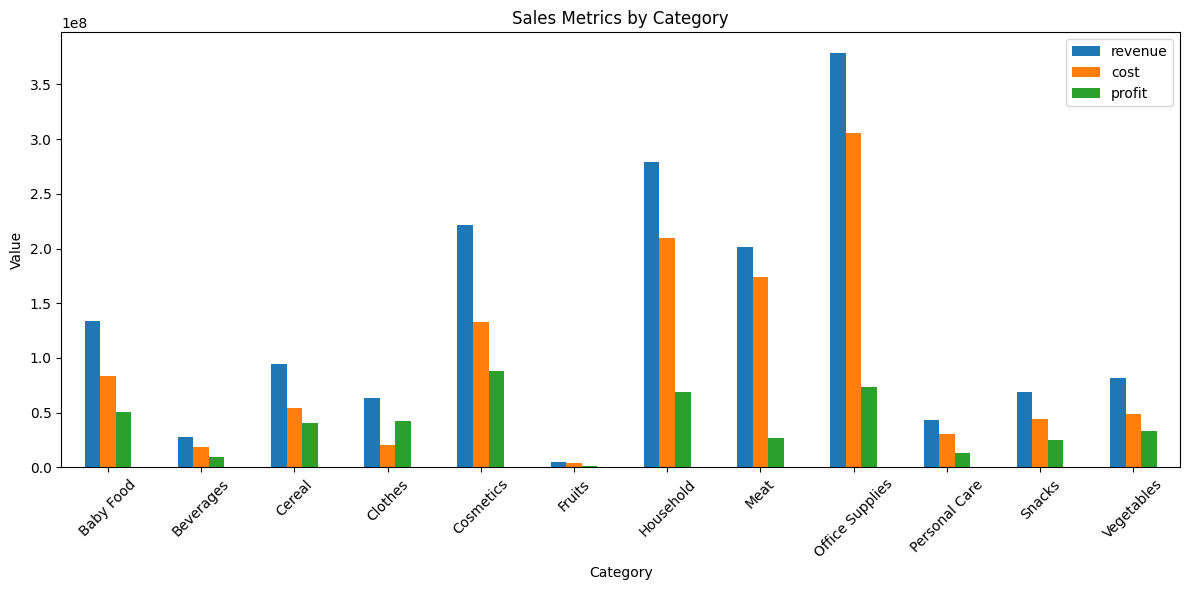

In [ ]:
# Aggregate sales metrics by product category
import seaborn as sns
import matplotlib.pyplot as plt

category_stats = df.groupby("category")[["revenue", "cost", "profit", "units_sold"]].sum()
# Sales metrics (revenue, cost, profit) by product category
category_stats[["revenue", "cost", "profit"]].plot(kind="bar", figsize=(12, 6))
plt.title("Sales Metrics by Category")
plt.xlabel("Category")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Office Supplies generates the highest revenue but has a low profit margin due to high costs. Cosmetics, despite lower revenue, delivers the highest profit — making it the most financially efficient category. Fruits and Beverages show minimal performance and may require strategic review. The company should consider increasing investment in Cosmetics and Household categories to maximize profitability.

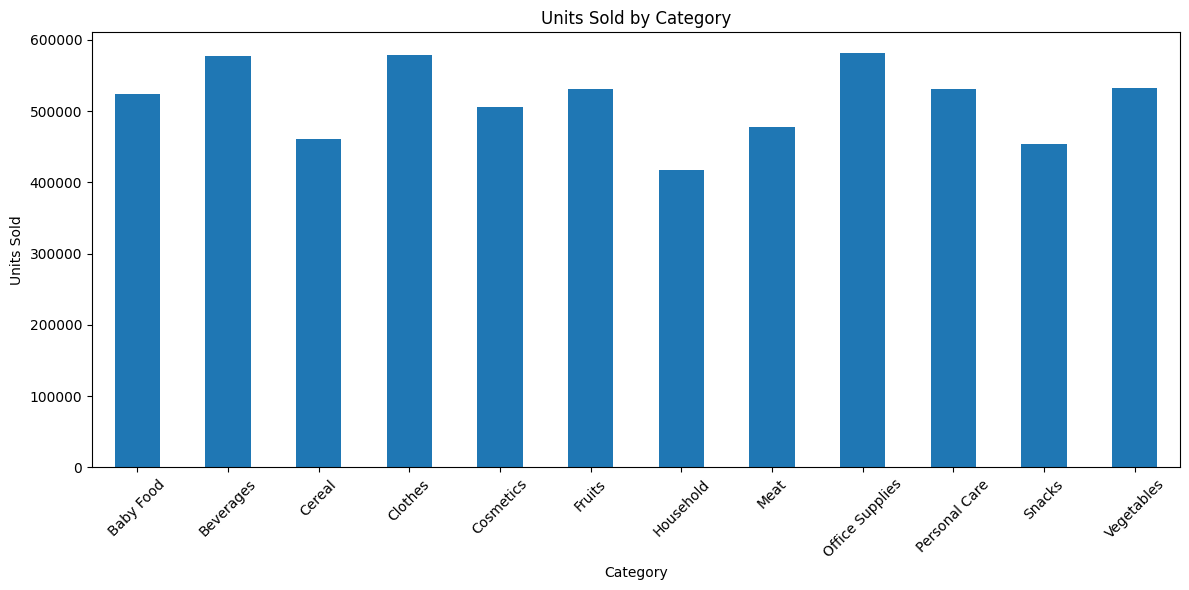

In [ ]:
# Units sold by product category
category_stats["units_sold"].plot(kind="bar", figsize=(12, 6))
plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Units sold are relatively uniform across all categories (~400K–580K), with Office Supplies and Clothes leading in volume. However, high sales volume does not guarantee high profit — Fruits sells ~530K units but generates near-zero profit, indicating very low margins. Cosmetics achieves strong profitability with moderate volume, confirming it as the most efficient category.

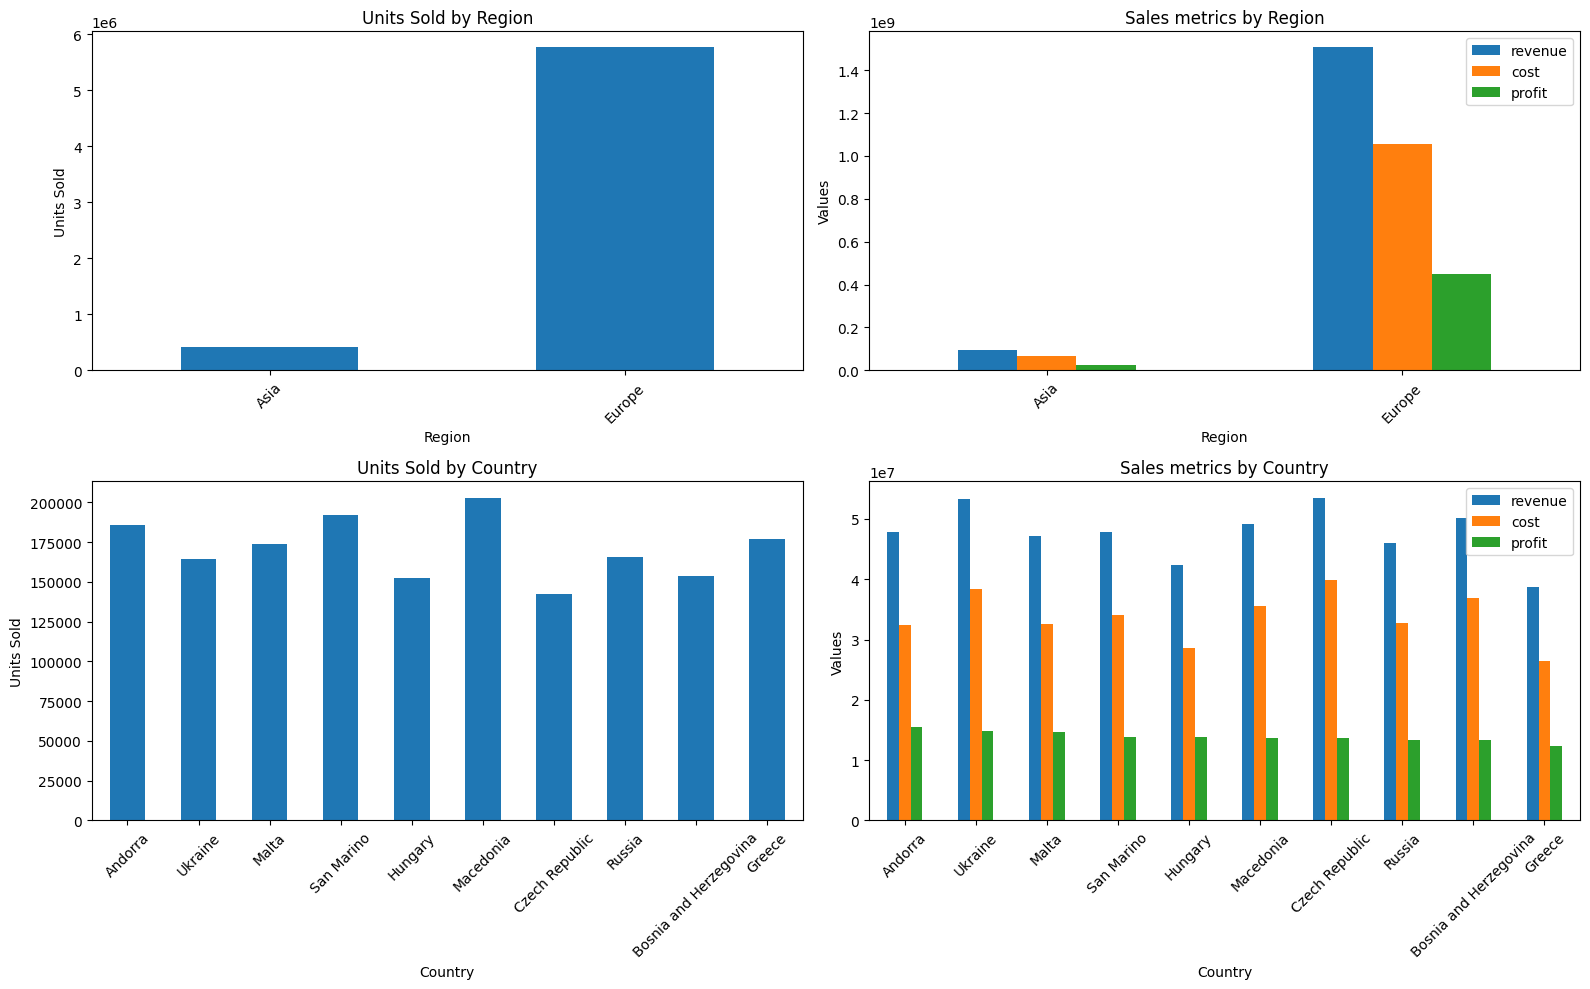

In [ ]:
# Sales metrics and units sold by region and top-10 countries by profit
grouped_by_region = df.groupby("region")[["revenue", "cost", "profit", "units_sold"]].sum()
grouped_by_country = df.groupby("name")[["revenue", "cost", "profit", "units_sold"]].sum()
top10_countries = grouped_by_country.nlargest(10, "profit")

fig, axes = plt.subplots(2,2, figsize=(16, 10))
grouped_by_region["units_sold"].plot(kind="bar", ax = axes[0,0])
axes[0,0].set_title("Units Sold by Region")
axes[0,0].set_xlabel("Region")
axes[0,0].set_ylabel("Units Sold")
axes[0,0].tick_params(axis='x', rotation=45)

grouped_by_region[["revenue", "cost", "profit"]].plot(kind="bar", ax = axes[0,1])
axes[0,1].set_title("Sales metrics by Region")
axes[0,1].set_xlabel("Region")
axes[0,1].set_ylabel("Values")
axes[0,1].tick_params(axis='x', rotation=45)

top10_countries["units_sold"].plot(kind="bar", ax = axes[1,0])
axes[1,0].set_title("Units Sold by Country")
axes[1,0].set_xlabel("Country")
axes[1,0].set_ylabel("Units Sold")
axes[1,0].tick_params(axis='x', rotation=45)

top10_countries[["revenue", "cost", "profit"]].plot(kind="bar", ax = axes[1,1])
axes[1,1].set_title("Sales metrics by Country")
axes[1,1].set_xlabel("Country")
axes[1,1].set_ylabel("Values")
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



Europe dominates all metrics — ~ 5.8M units sold vs ~ 0.4M in Asia, and ~ 10x higher revenue and profit. The business is heavily concentrated in the European market. Among top-10 countries by profit, Macedonia leads in units sold, while Czech Republic and Ukraine generate the highest revenue. Profit margins are relatively uniform across countries (~13 – 16M),
suggesting consistent pricing strategy regardless of country.



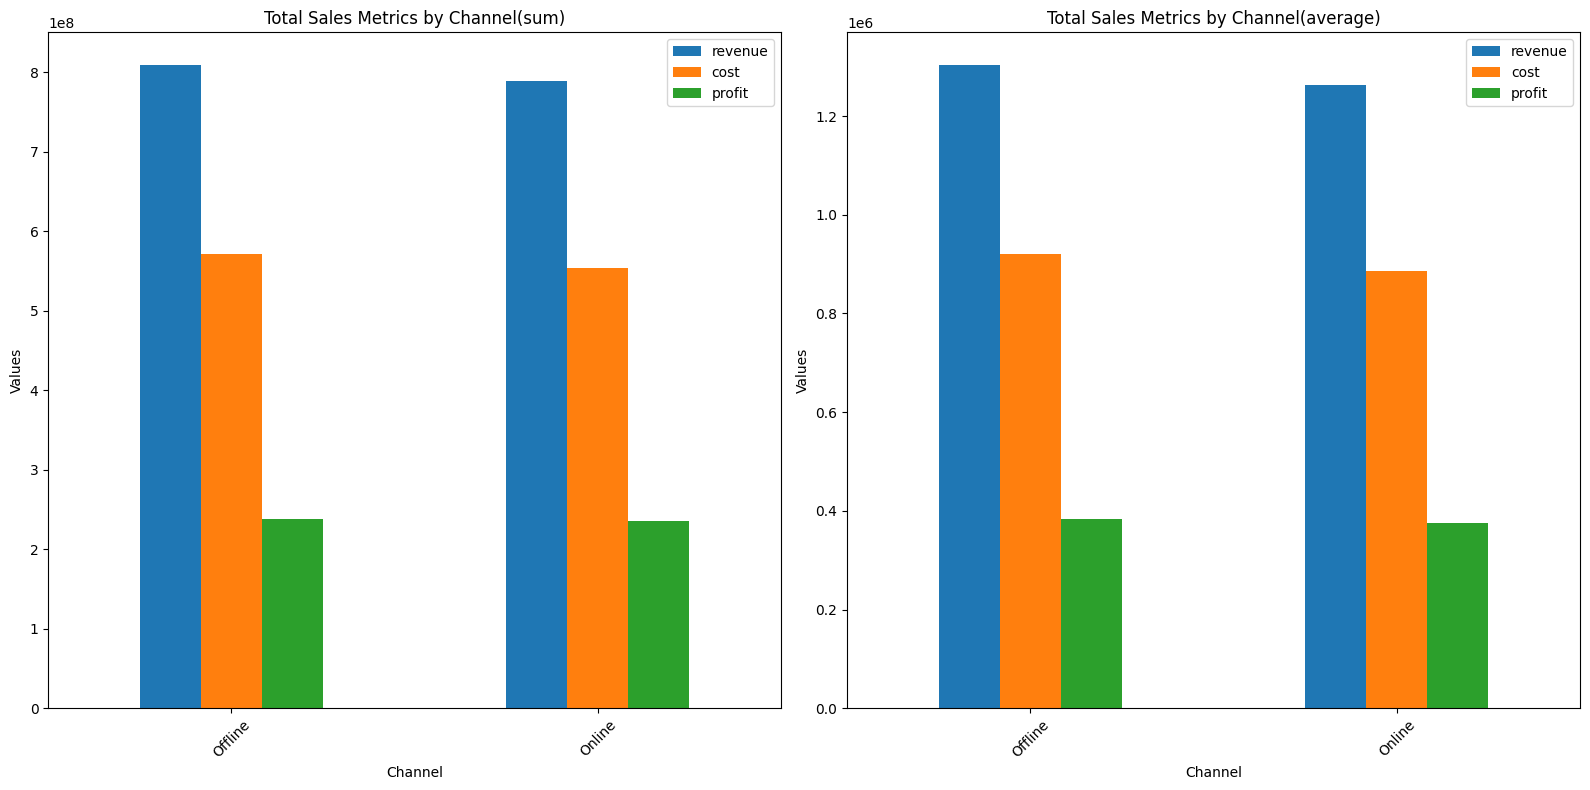

In [ ]:
# Total and average sales metrics by sales channel (online vs offline)
grouped_by_channel_sum = df.groupby("sales_channel")[["revenue", "cost", "profit", "units_sold"]].sum()
grouped_by_channel_avg = df.groupby("sales_channel")[["revenue", "cost", "profit", "units_sold"]].mean()

fig, axes = plt.subplots(1,2, figsize=(16, 8))

grouped_by_channel_sum[["revenue", "cost", "profit"]].plot(kind="bar", ax = axes[0])
axes[0].set_title("Total Sales Metrics by Channel(sum)")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Values")
axes[0].tick_params(axis='x', rotation=45)

grouped_by_channel_avg[["revenue", "cost", "profit"]].plot(kind="bar", ax = axes[1])
axes[1].set_title("Total Sales Metrics by Channel(average)")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Values")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Offline and Online channels perform almost identically across all metrics — both total and average revenue, cost, and profit are nearly equal. Offline has a slight edge in total revenue (~810M vs ~790M) and average profit per order is marginally higher offline. This suggests the company has a well-balanced multi-channel strategy, with neither channel significantly outperforming the other.

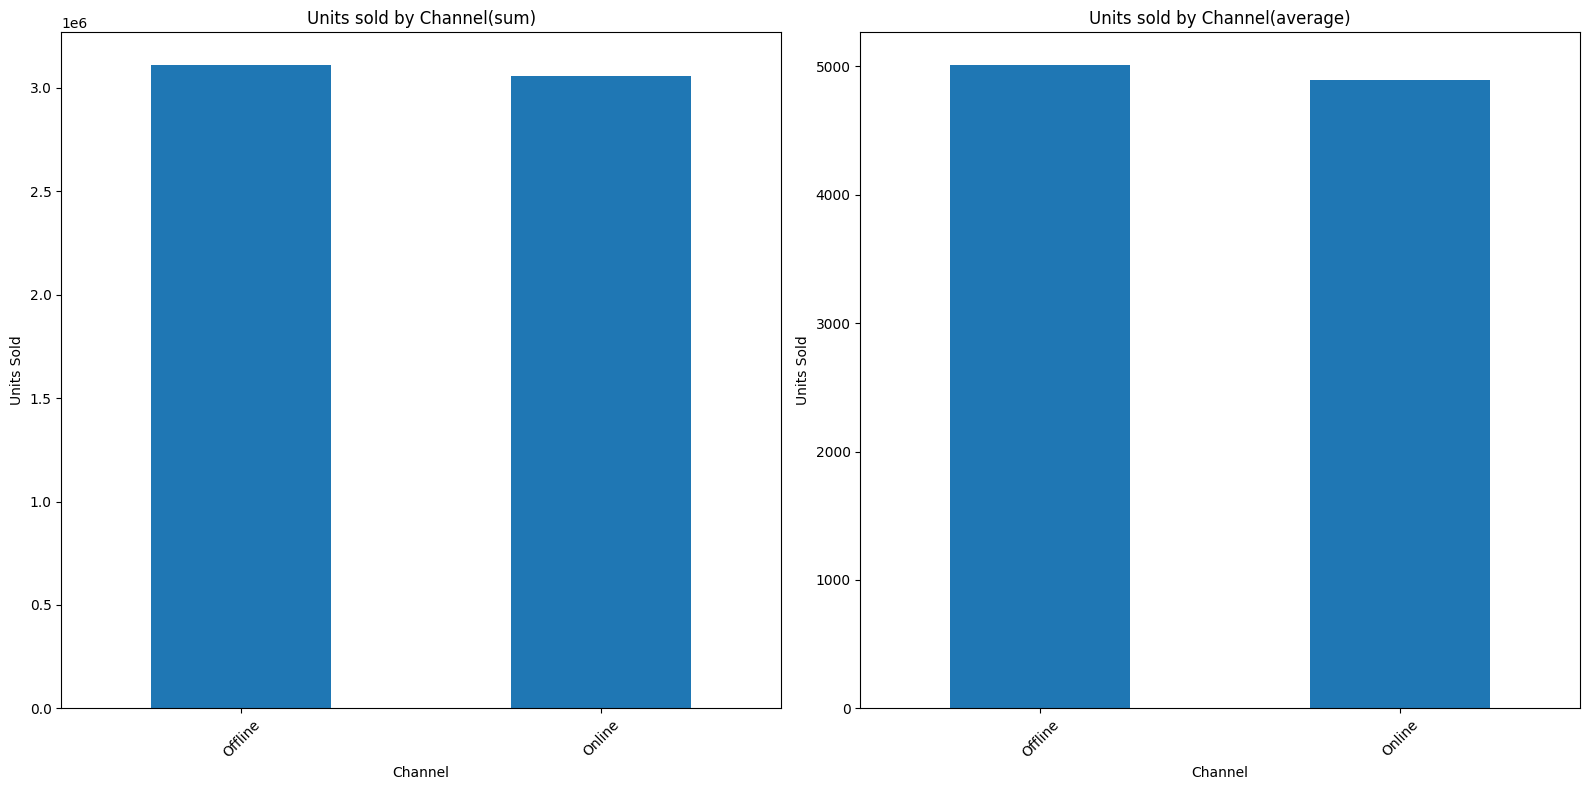

In [ ]:
# Total and average units sold by sales channel (online vs offline)
fig, axes = plt.subplots(1,2, figsize=(16, 8))

grouped_by_channel_sum["units_sold"].plot(kind="bar", ax = axes[0])
axes[0].set_title("Units sold by Channel(sum)")
axes[0].set_xlabel("Channel")
axes[0].set_ylabel("Units Sold")
axes[0].tick_params(axis='x', rotation=45)

grouped_by_channel_avg["units_sold"].plot(kind="bar", ax = axes[1])
axes[1].set_title("Units sold by Channel(average)")
axes[1].set_xlabel("Channel")
axes[1].set_ylabel("Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Units sold further confirms channel balance — Offline (~ 3.1M) and Online (~ 3.07M) are nearly identical in both total and average volume.

In [ ]:
df.dtypes

,0
order_id,int64
order_date,datetime64[ns]
ship_date,datetime64[ns]
order_priority,object
country_code,object
product_id,int64
sales_channel,object
units_sold,float64
unit_price,float64
unit_cost,float64


In [ ]:
# Calculate shipping interval in days
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,category,name,region,sub_region,revenue,cost,profit,shipping_days
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,76121.50,57583.50,10
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,233400.23,176559.87,0
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,41968.64,85998.24,31
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,243129.92,119767.68,38
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,1165411.20,280275.00,34


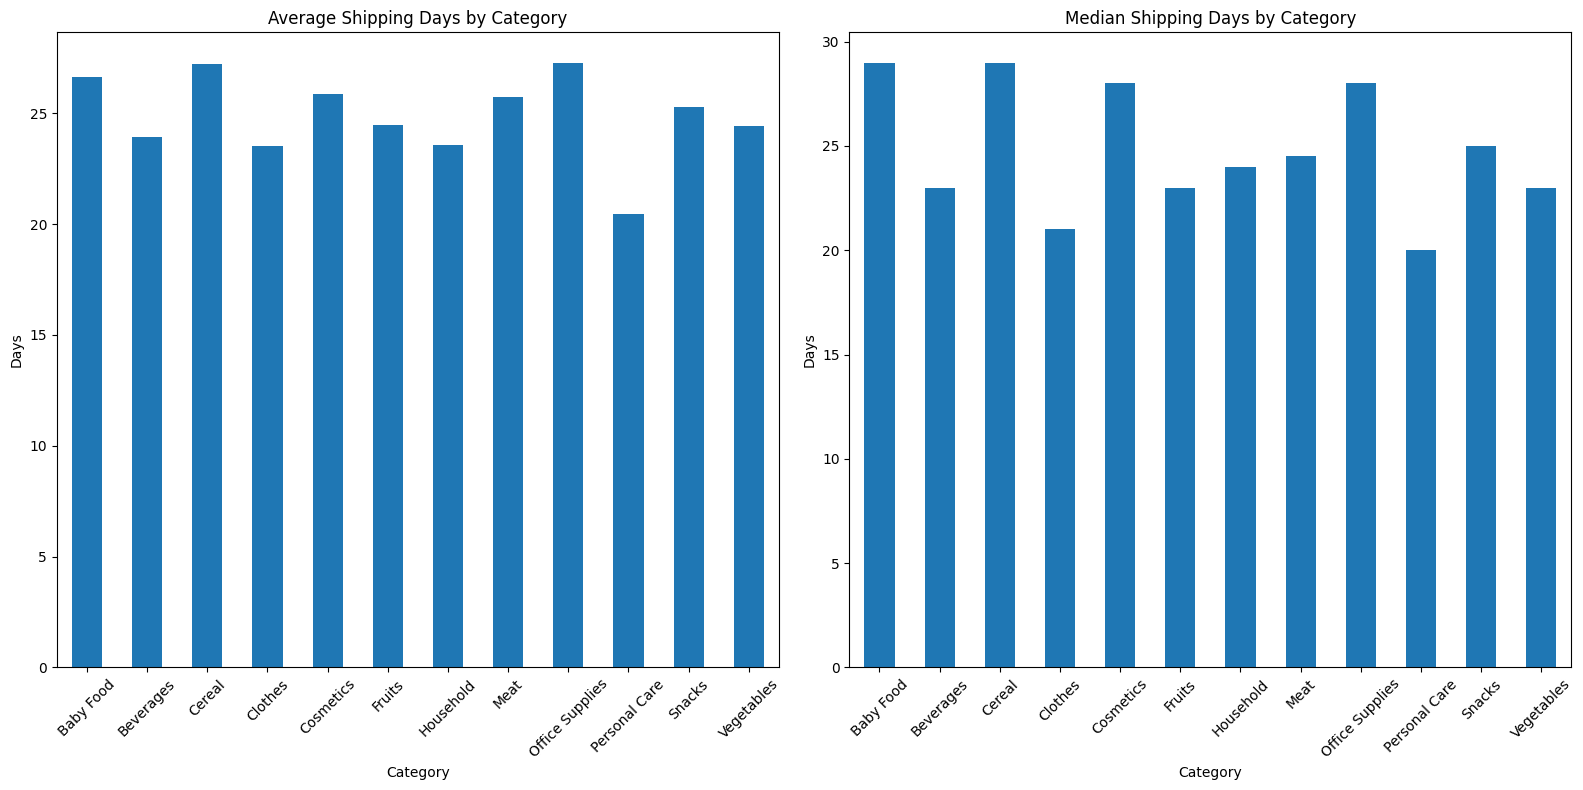

In [ ]:
# Average and median shipping days by product category
groupped_by_category_days_median = df.groupby("category")["shipping_days"].median()
groupped_by_category_days_mean = df.groupby("category")["shipping_days"].mean()
fig, axes = plt.subplots(1,2, figsize=(16, 8))

groupped_by_category_days_mean.plot(kind="bar", ax = axes[0])
axes[0].set_title("Average Shipping Days by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis='x', rotation=45)

groupped_by_category_days_median.plot(kind="bar", ax = axes[1])
axes[1].set_title("Median Shipping Days by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Days")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Shipping times are relatively uniform across all categories (20–27 days average). Personal Care has the fastest shipping (~ 20.5 days avg,    ~ 20 days median), while Office Supplies and Cereal are the slowest (~27 days). The gap between average and median for some categories (e.g. Baby Food, Cereal) suggests occasional outlier orders with very long shipping times pulling the average up.

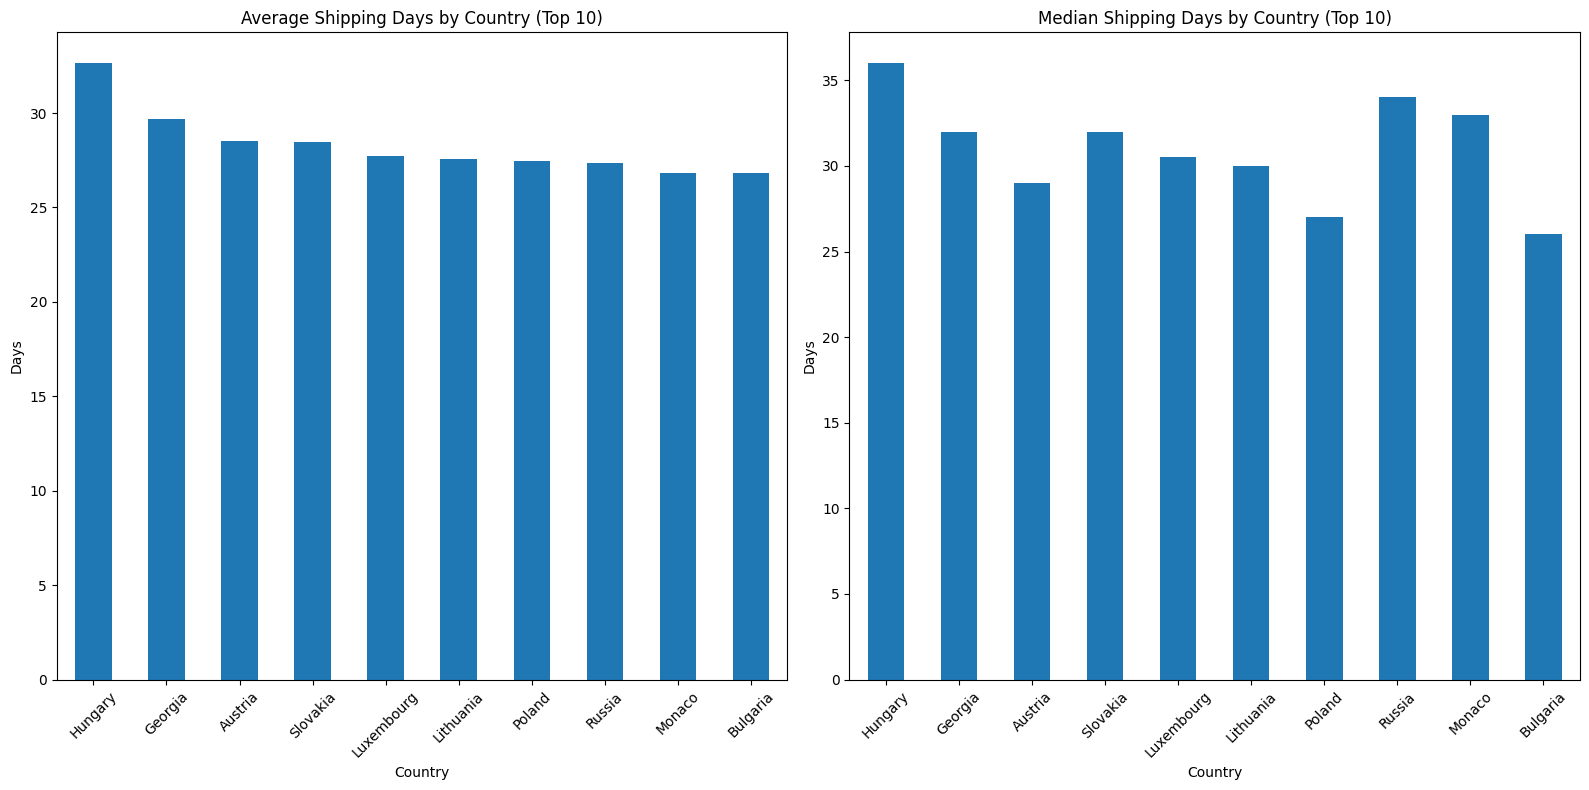

In [ ]:
# Average and median shipping days for top-10 countries
groupped_by_country_median = df.groupby("name")["shipping_days"].median()
groupped_by_country_mean = df.groupby("name")["shipping_days"].mean()
top_10_countries_days = groupped_by_country_mean.nlargest(10)
top_10_countries_median_days = groupped_by_country_median[top_10_countries_days.index]
fig, axes = plt.subplots(1,2, figsize=(16, 8))

top_10_countries_days.plot(kind="bar", ax = axes[0])
axes[0].set_title("Average Shipping Days by Country (Top 10)")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis='x', rotation=45)

top_10_countries_median_days.plot(kind="bar", ax = axes[1])
axes[1].set_title("Median Shipping Days by Country (Top 10)")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Days")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Hungary has the longest average shipping time (~ 33 days, median ~ 36 days), followed by Georgia (~ 30 days). Bulgaria and Poland have the shortest times among the top-10 slowest countries (~27 days). Notably, the median is consistently higher than the average for most countries, which is unusual and may indicate that most orders take longer than the mean suggests — worth investigating further.

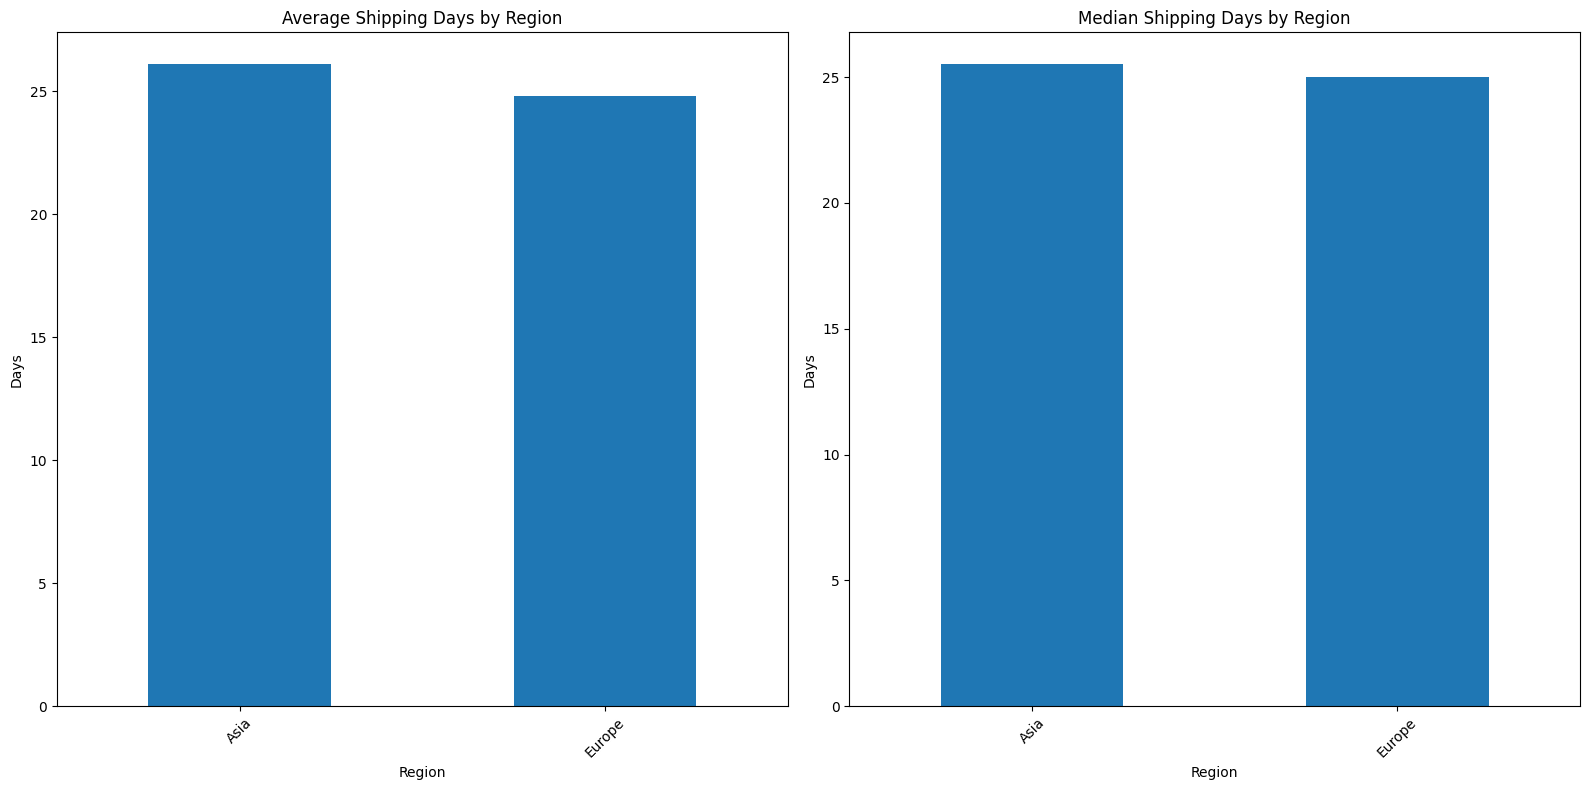

In [ ]:
# Average and median shipping days by region
groupped_by_region_mean = df.groupby("region")["shipping_days"].mean()
groupped_by_region_median = df.groupby("region")["shipping_days"].median()
fig, axes = plt.subplots(1,2, figsize=(16, 8))

groupped_by_region_mean.plot(kind="bar", ax = axes[0])
axes[0].set_title("Average Shipping Days by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Days")
axes[0].tick_params(axis='x', rotation=45)

groupped_by_region_median.plot(kind="bar", ax = axes[1])
axes[1].set_title("Median Shipping Days by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Days")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Asia has slightly longer shipping times than Europe (avg ~26 vs ~25 days, median ~26 vs ~25 days). The difference is minimal, suggesting the company maintains consistent logistics performance across both regions.

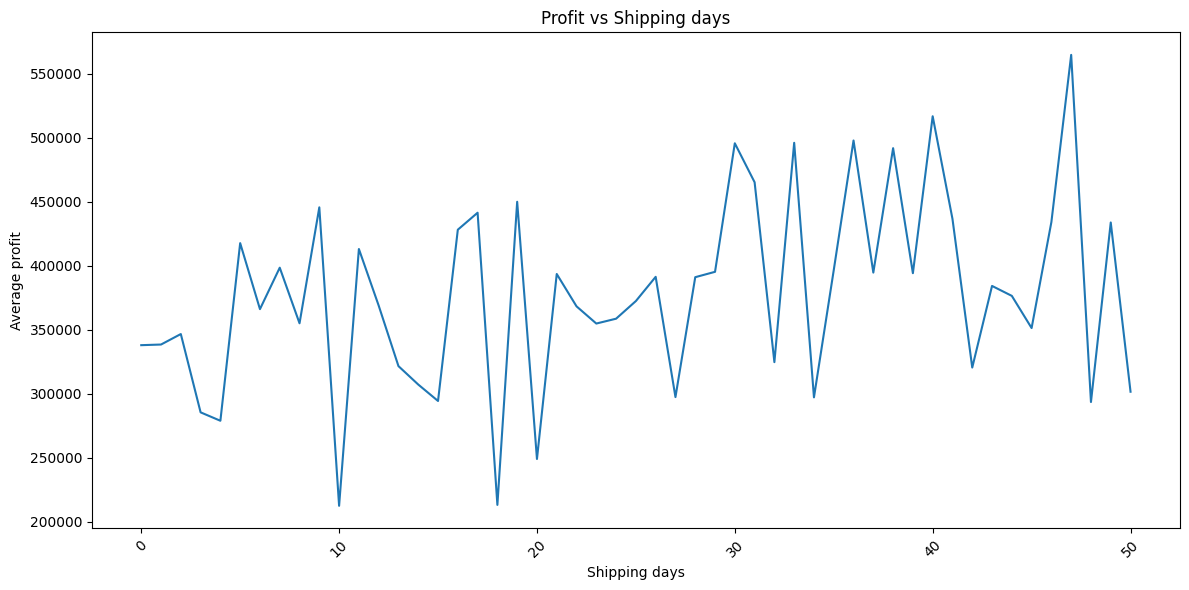

In [ ]:
# Profit vs shipping days analysis
grouped_by_days = df.groupby("shipping_days")["profit"].mean()
grouped_by_days.plot(kind="line", figsize=(12, 6))
plt.title("Profit vs Shipping days")
plt.xlabel("Shipping days")
plt.ylabel("Average profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There is no clear linear relationship between shipping time and profit. The chart shows high volatility throughout, with profit fluctuating between ~210K and ~565K regardless of shipping duration. However, there is a slight upward trend — orders with longer shipping times (30–50 days) tend to have somewhat higher average profit. This likely reflects the nature of high-value products (e.g. Office Supplies) which may require more processing time rather than shipping speed causing higher profit.

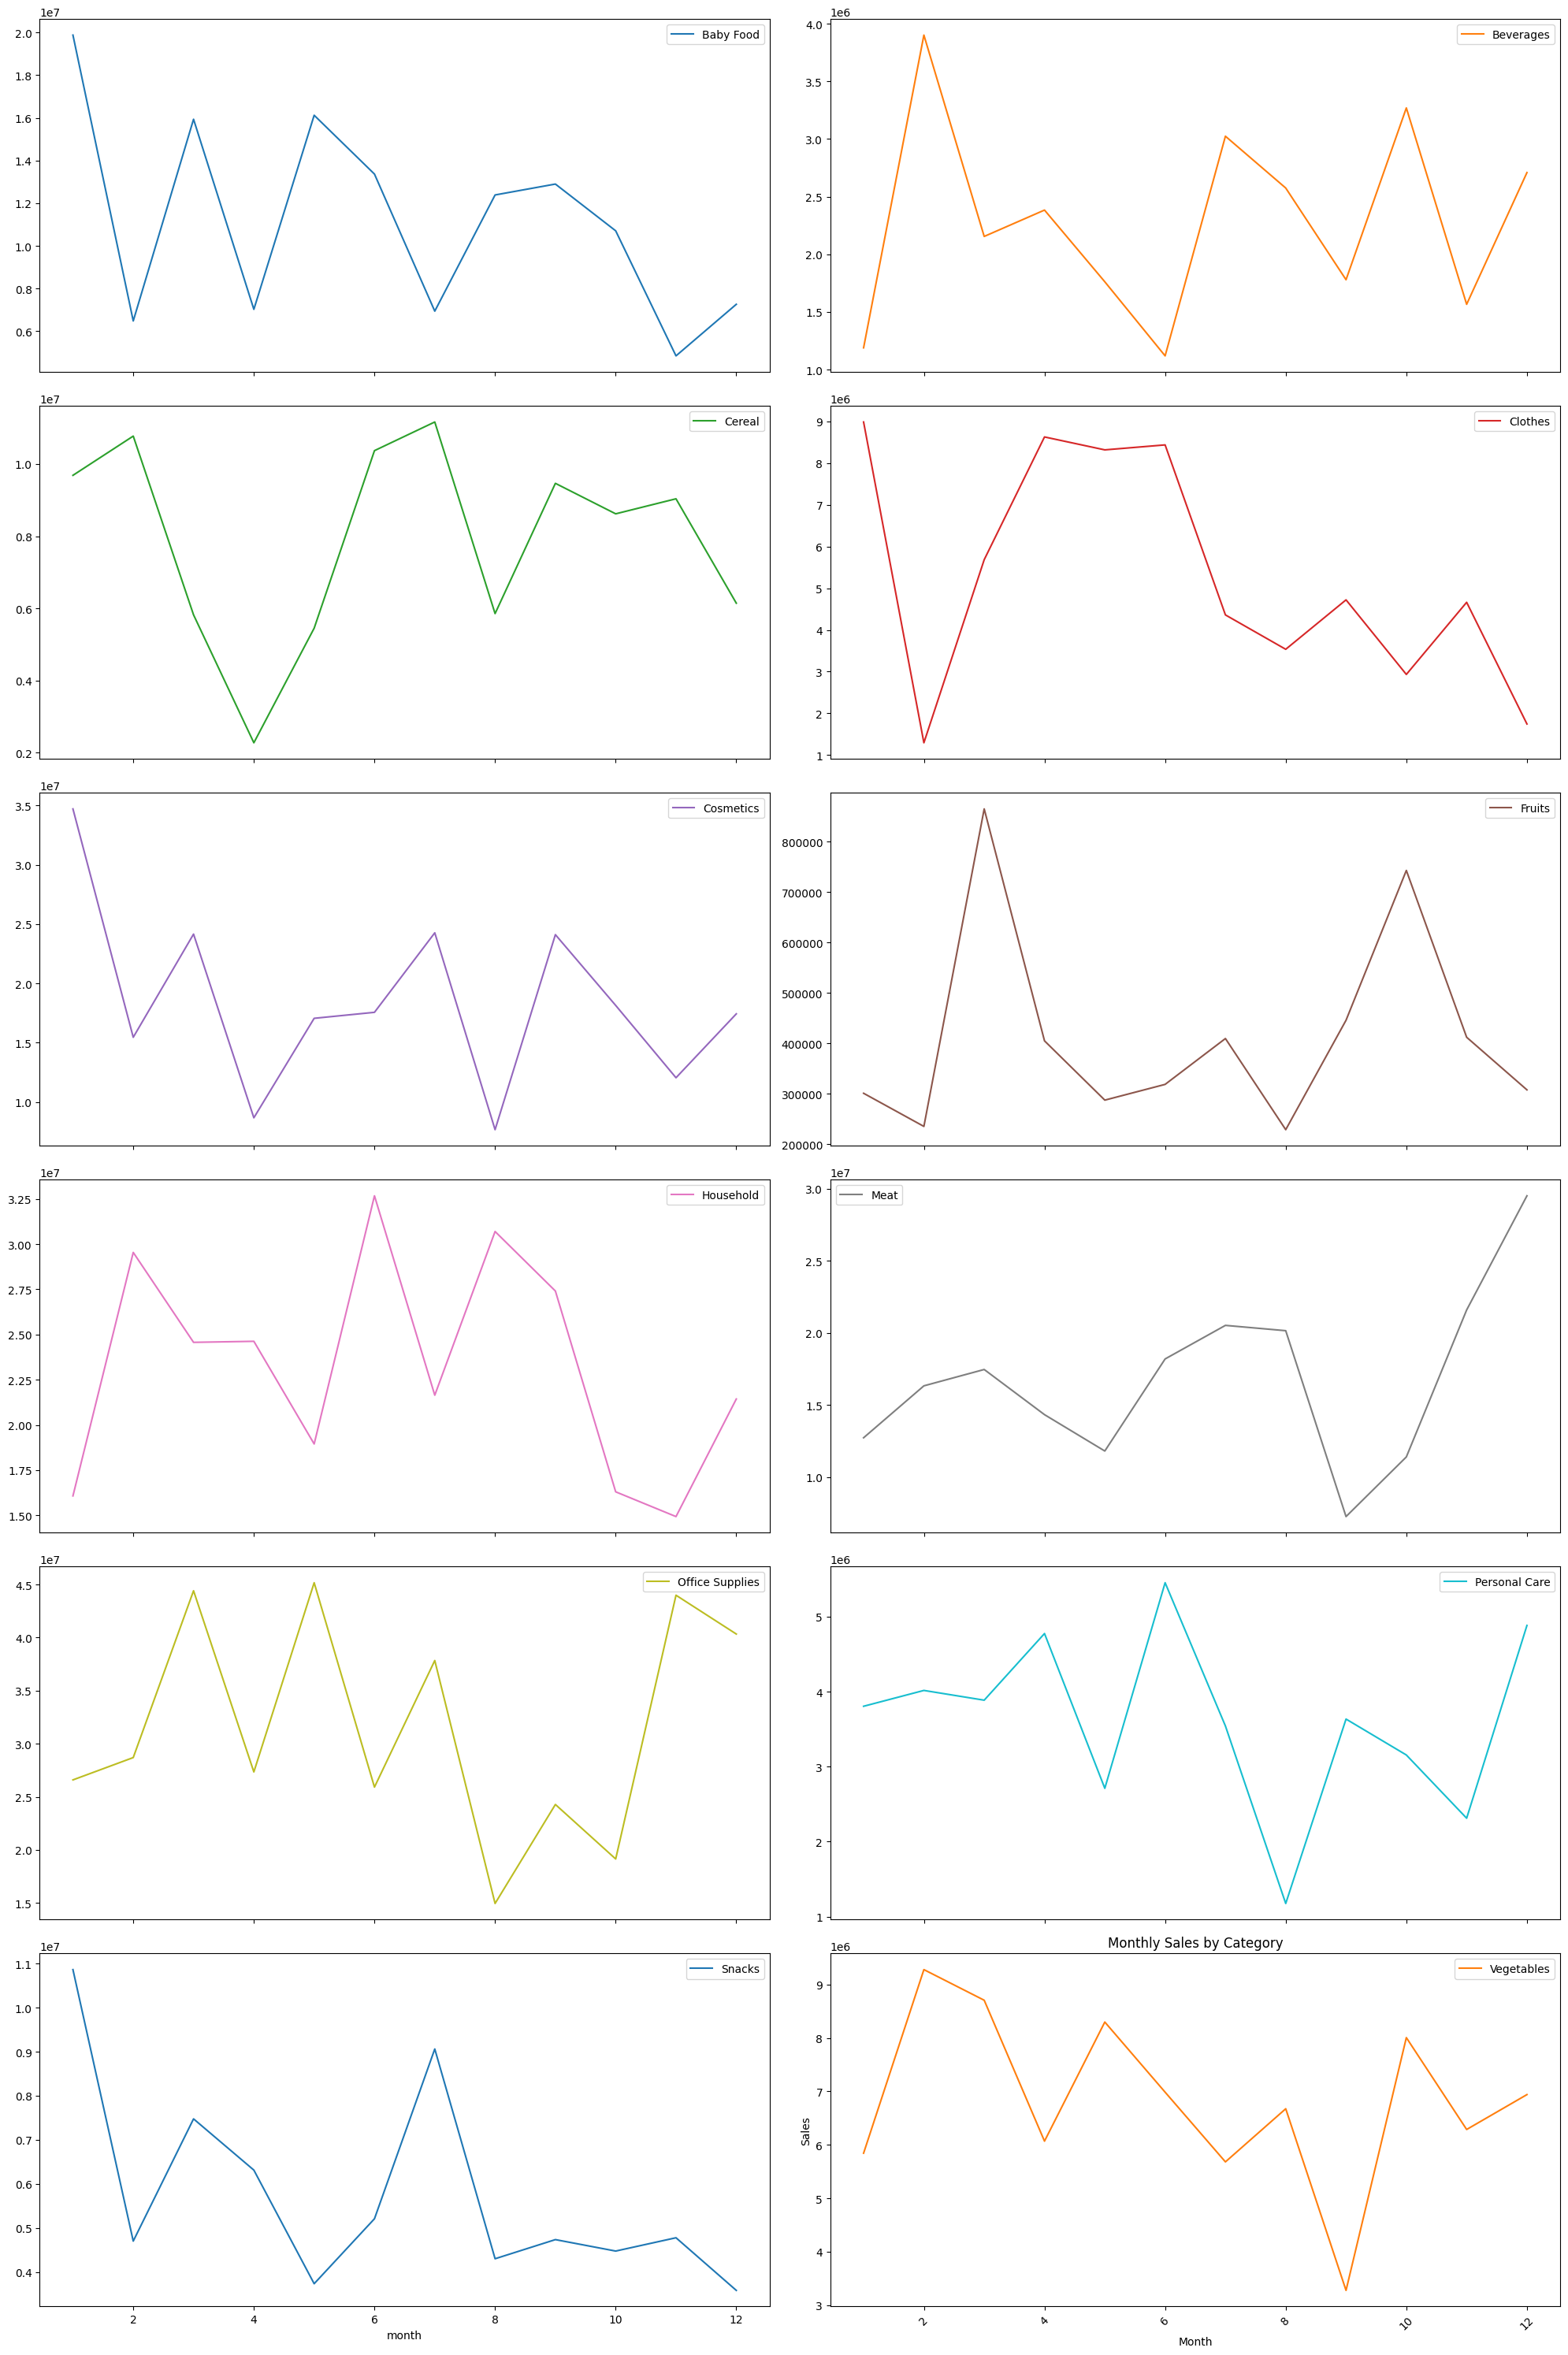

In [ ]:
# Sales dynamics over time by category
df["month"] = df["order_date"].dt.month
groupped_by_year = df.groupby(["month", "category"])["revenue"].sum().unstack("category")
groupped_by_year.plot(kind="line", figsize=(20, 30), subplots=True, layout=(6, 2))
plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Office Supplies shows the highest and most volatile monthly sales, with sharp peaks in March (~44M) and May (~45M), followed by a significant drop in summer months. Household is the second most volatile category, peaking in August (~31M) and January (~35M). Cosmetics shows a gradual upward trend from mid-year, peaking in December. Most remaining categories (Beverages, Clothes, Cereal, Personal Care, Fruits) remain consistently low and flat throughout the year. Fruits shows near-zero sales across all months, confirming it as the weakest category. Overall, Q1 (January–March) and Q2 (April–June) are the strongest periods driven primarily by Office Supplies and Household.

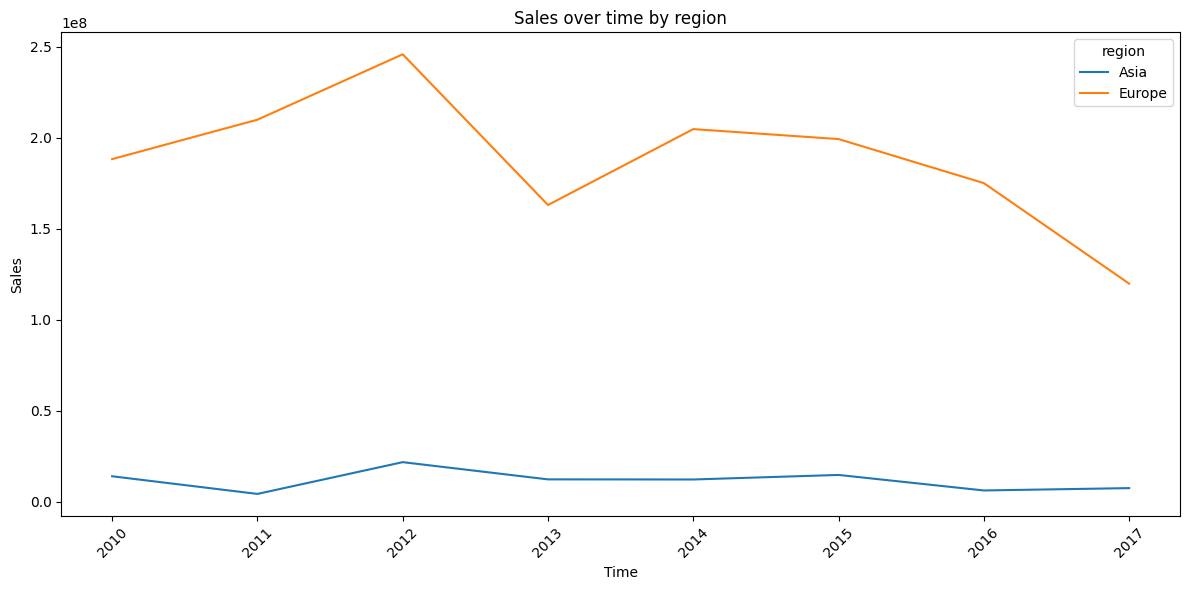

In [ ]:
# Sales dynamics over time by region
groupped_by_year_region = df.groupby([df["order_date"].dt.year, "region"])["revenue"].sum().unstack("region")
groupped_by_year_region.plot(kind="line", figsize=(12, 6))
plt.title("Sales over time by region")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Europe peaked in 2012 (~ 245M) then dropped sharply in 2013 (~ 165M), recovered in 2014 – 2015 (~ 205M), and has been declining steadily since — reaching its lowest point in 2017 (~ 120M). This is a concerning downward trend for the company's primary market. Asia remains flat and negligible throughout all years (~10–25M), showing no meaningful growth despite 7 years of operations. The overall trajectory suggests the business is contracting rather than growing, which should be a key strategic concern — the company needs to either re-engage the European market or actively develop new markets.

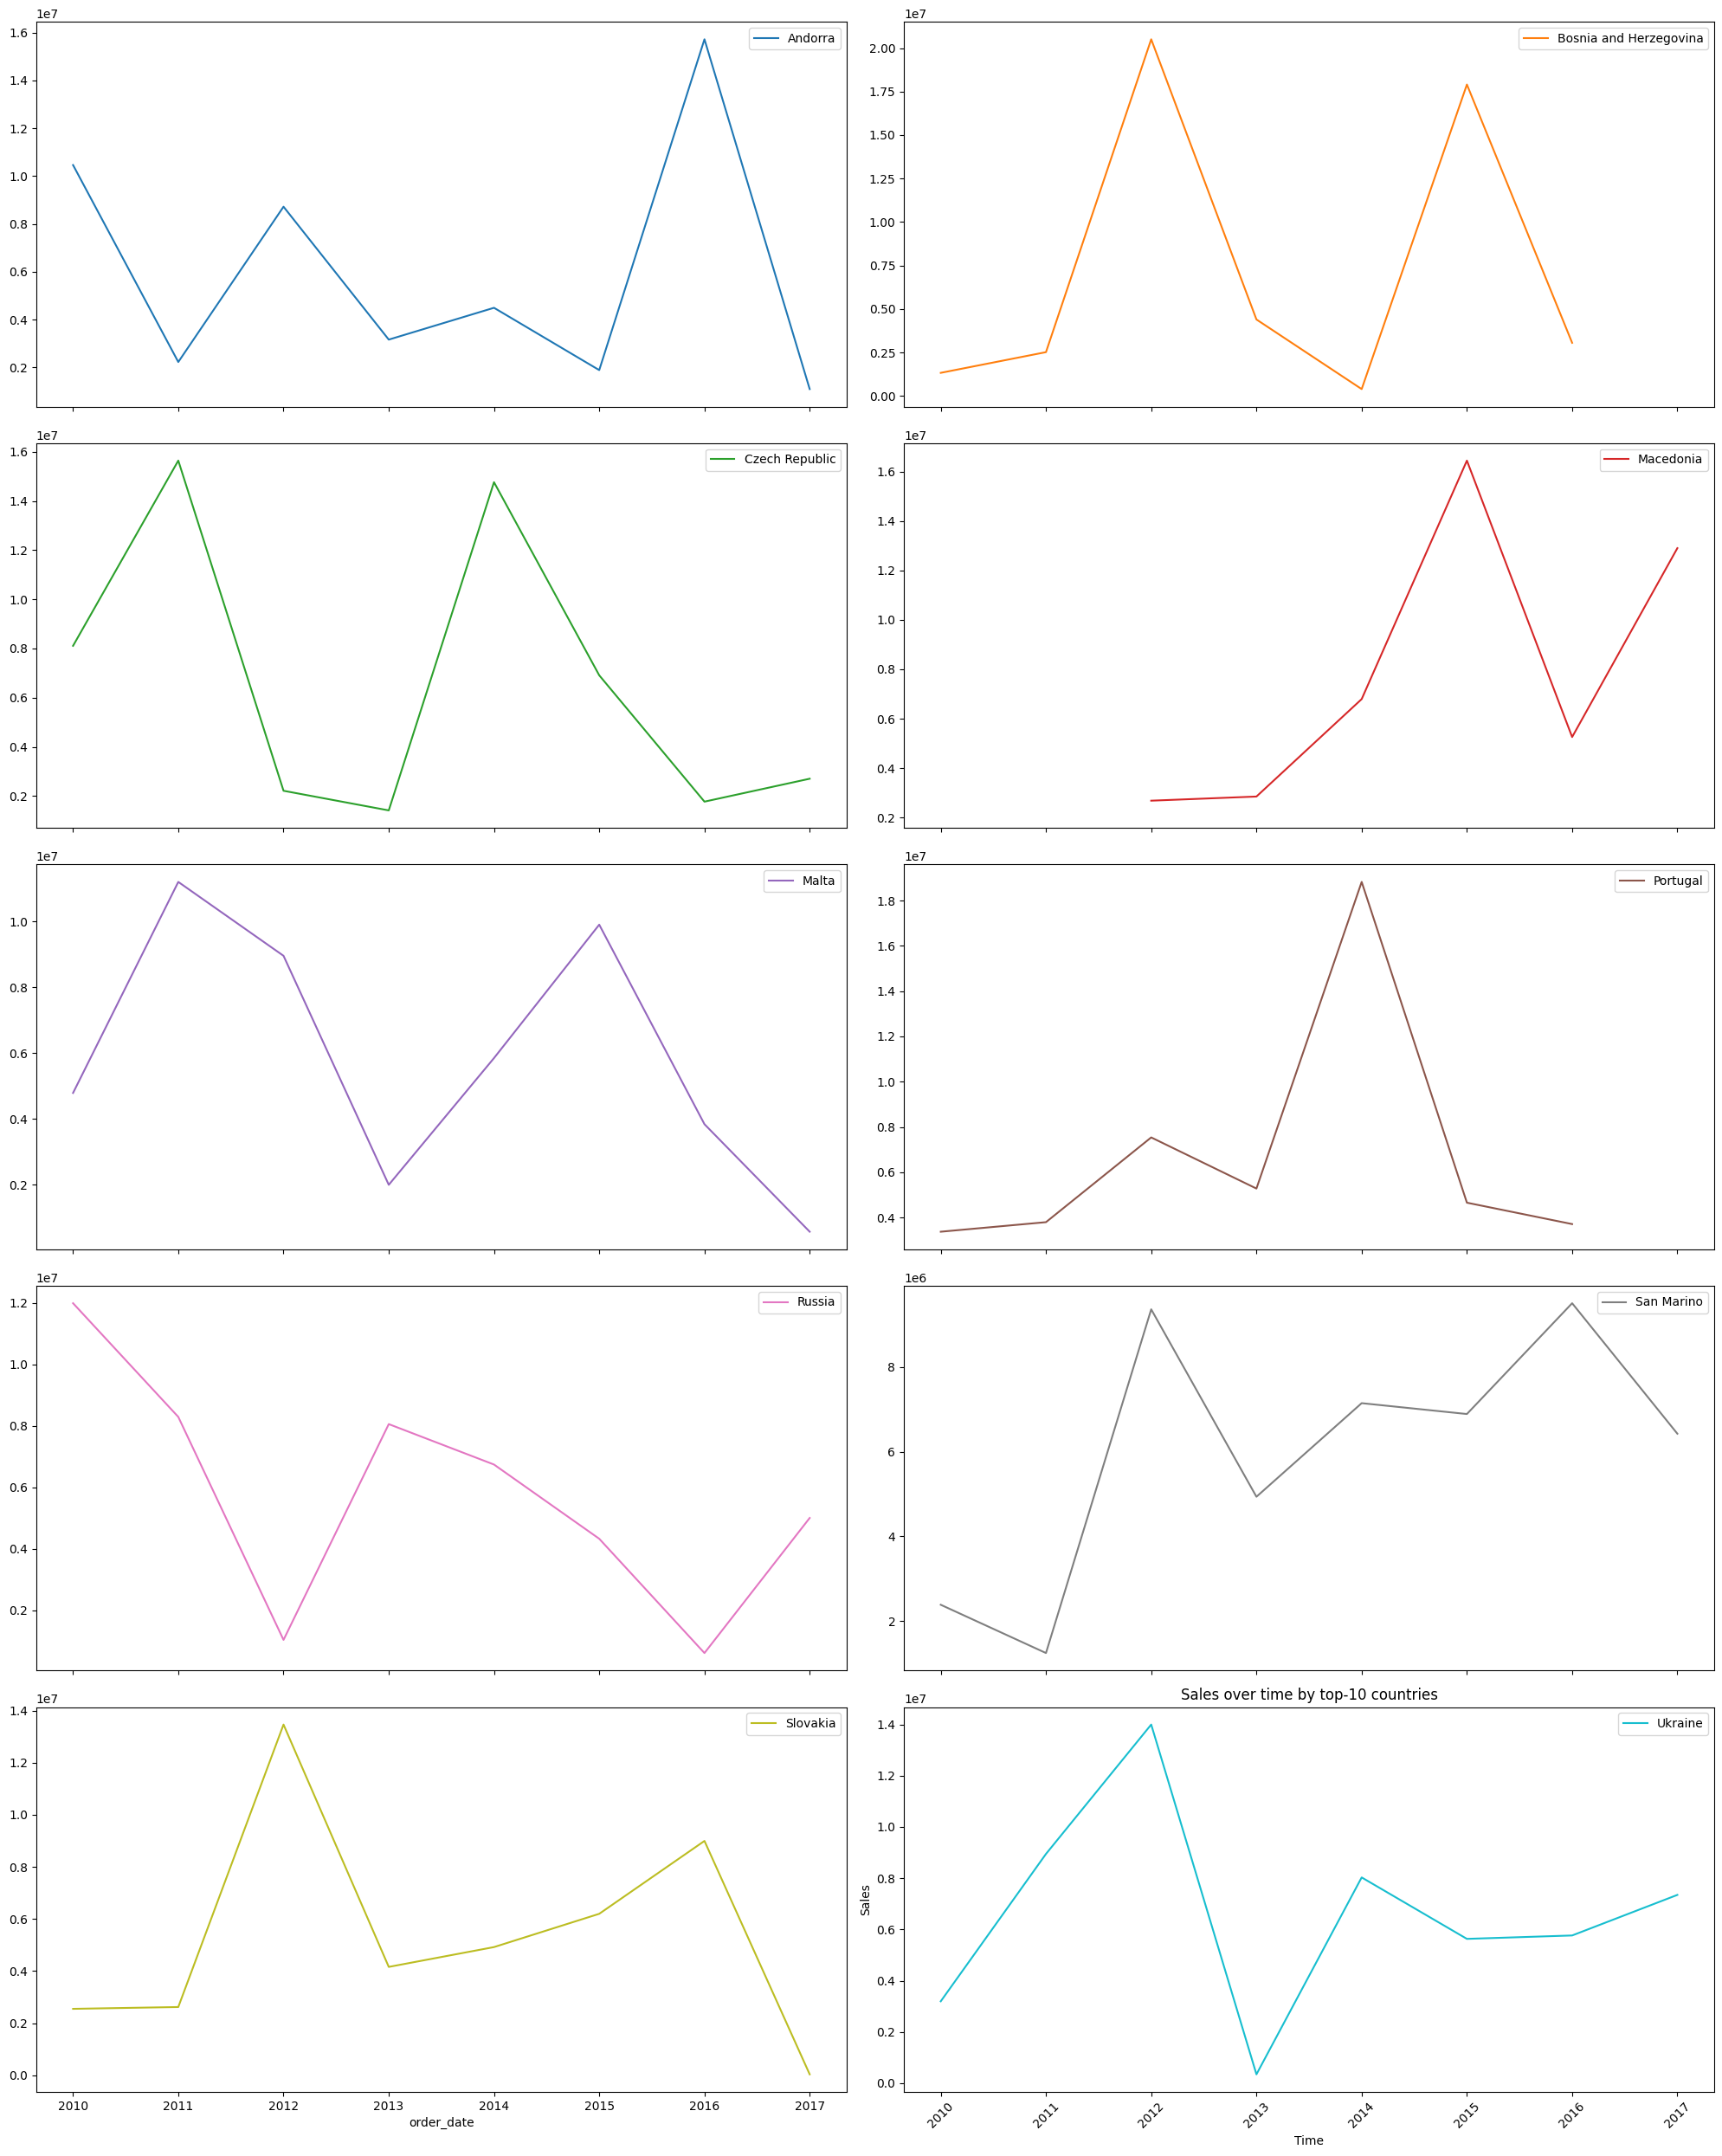

In [ ]:
# Sales dynamics over time by top-10 countries
top10 = df.groupby("name")["revenue"].sum().nlargest(10).index
df_top10 = df[df["name"].isin(top10)]
groupped_by_year_countries = df_top10.groupby([df_top10["order_date"].dt.year, "name"])["revenue"].sum().unstack("name")
groupped_by_year_countries.plot(kind="line", figsize=(20, 25), subplots=True, layout=(5, 2))
plt.title("Sales over time by top-10 countries")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Bosnia and Herzegovina recorded the highest single-year peak (~ 20.5M in 2012) but collapsed to near zero in 2013 and 2015, indicating highly irregular large orders. Portugal peaked in 2014 (~ 19M) and declined sharply afterward. Czech Republic was the strongest country in 2010–2011 (~ 15.5M) but shows a clear downward trend since. Macedonia spiked in 2015 (~16.5M) then dropped significantly. Russia is the only country showing a relatively stable and slightly upward trend throughout 2010–2017, making it the most consistent market. Most countries show no sustained growth — sales are driven by isolated large orders in specific years rather than consistent demand. This pattern across all top-10 countries confirms the overall European market contraction trend observed at the regional level.

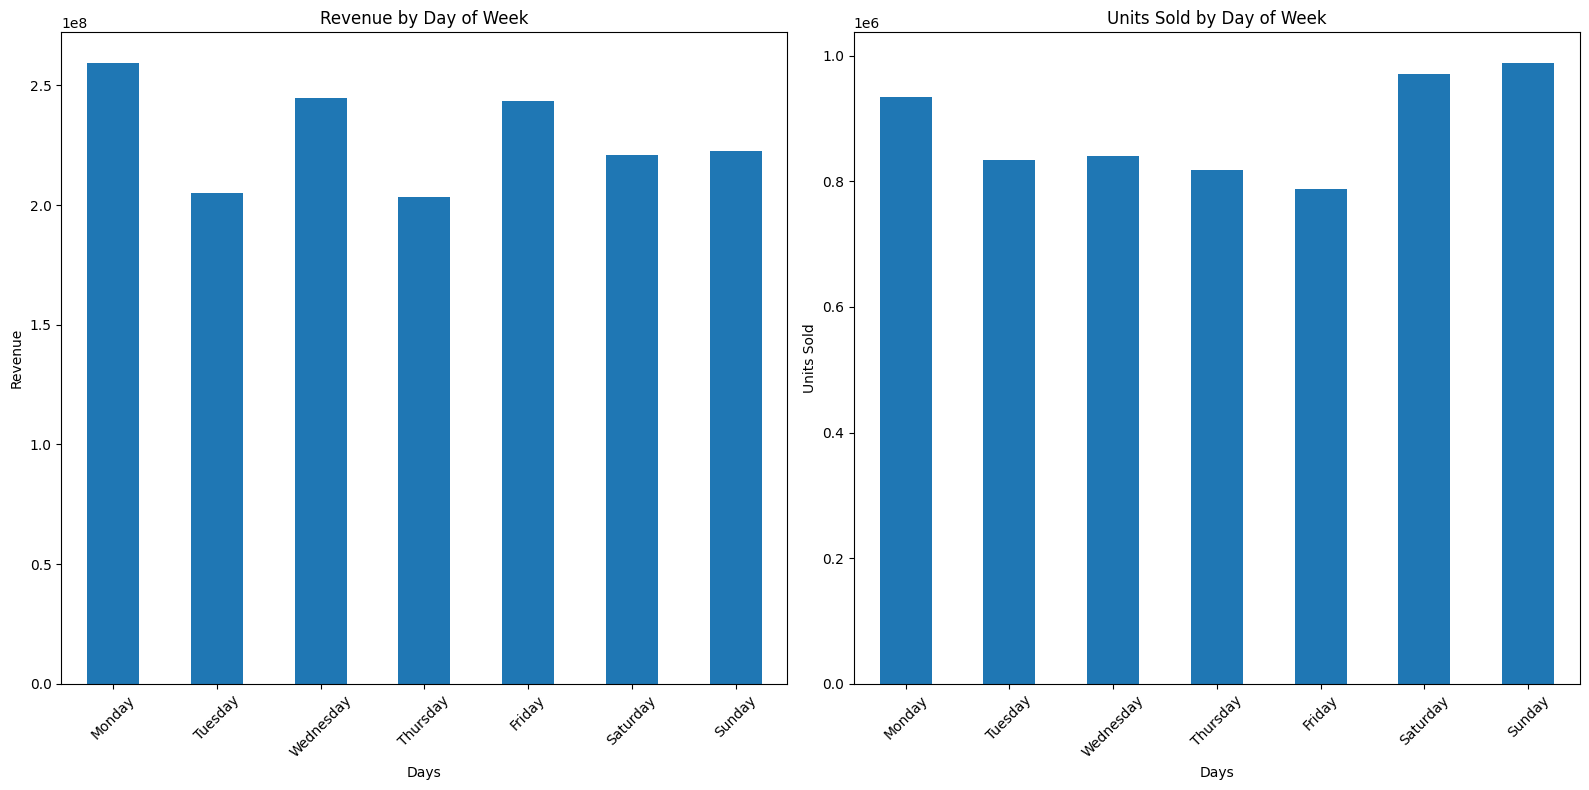

In [ ]:
# Sales analysis by day of week
df["day_of_week"] = df["order_date"].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
groupped_sales_by_day_revenue = df.groupby("day_of_week")["revenue"].sum().reindex(days_order)
groupped_sales_by_day_units = df.groupby("day_of_week")["units_sold"].sum().reindex(days_order)
fig, axes = plt.subplots(1,2, figsize=(16, 8))

groupped_sales_by_day_revenue.plot(kind="bar", ax = axes[0])
axes[0].set_title("Revenue by Day of Week")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis='x', rotation=45)

groupped_sales_by_day_units.plot(kind="bar", ax = axes[1])
axes[1].set_title("Units Sold by Day of Week")
axes[1].set_xlabel("Days")
axes[1].set_ylabel("Units Sold")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Monday generates the highest revenue (~ 260M) and units sold (~ 930K), while Tuesday and Thursday are the weakest days. Interestingly, the weekend (Saturday and Sunday) outperforms mid-week days in units sold, suggesting active weekend ordering — possibly from individual or B2C customers. Friday shows a dip compared to the start of the week, which is a common pattern in B2B sales cycles.

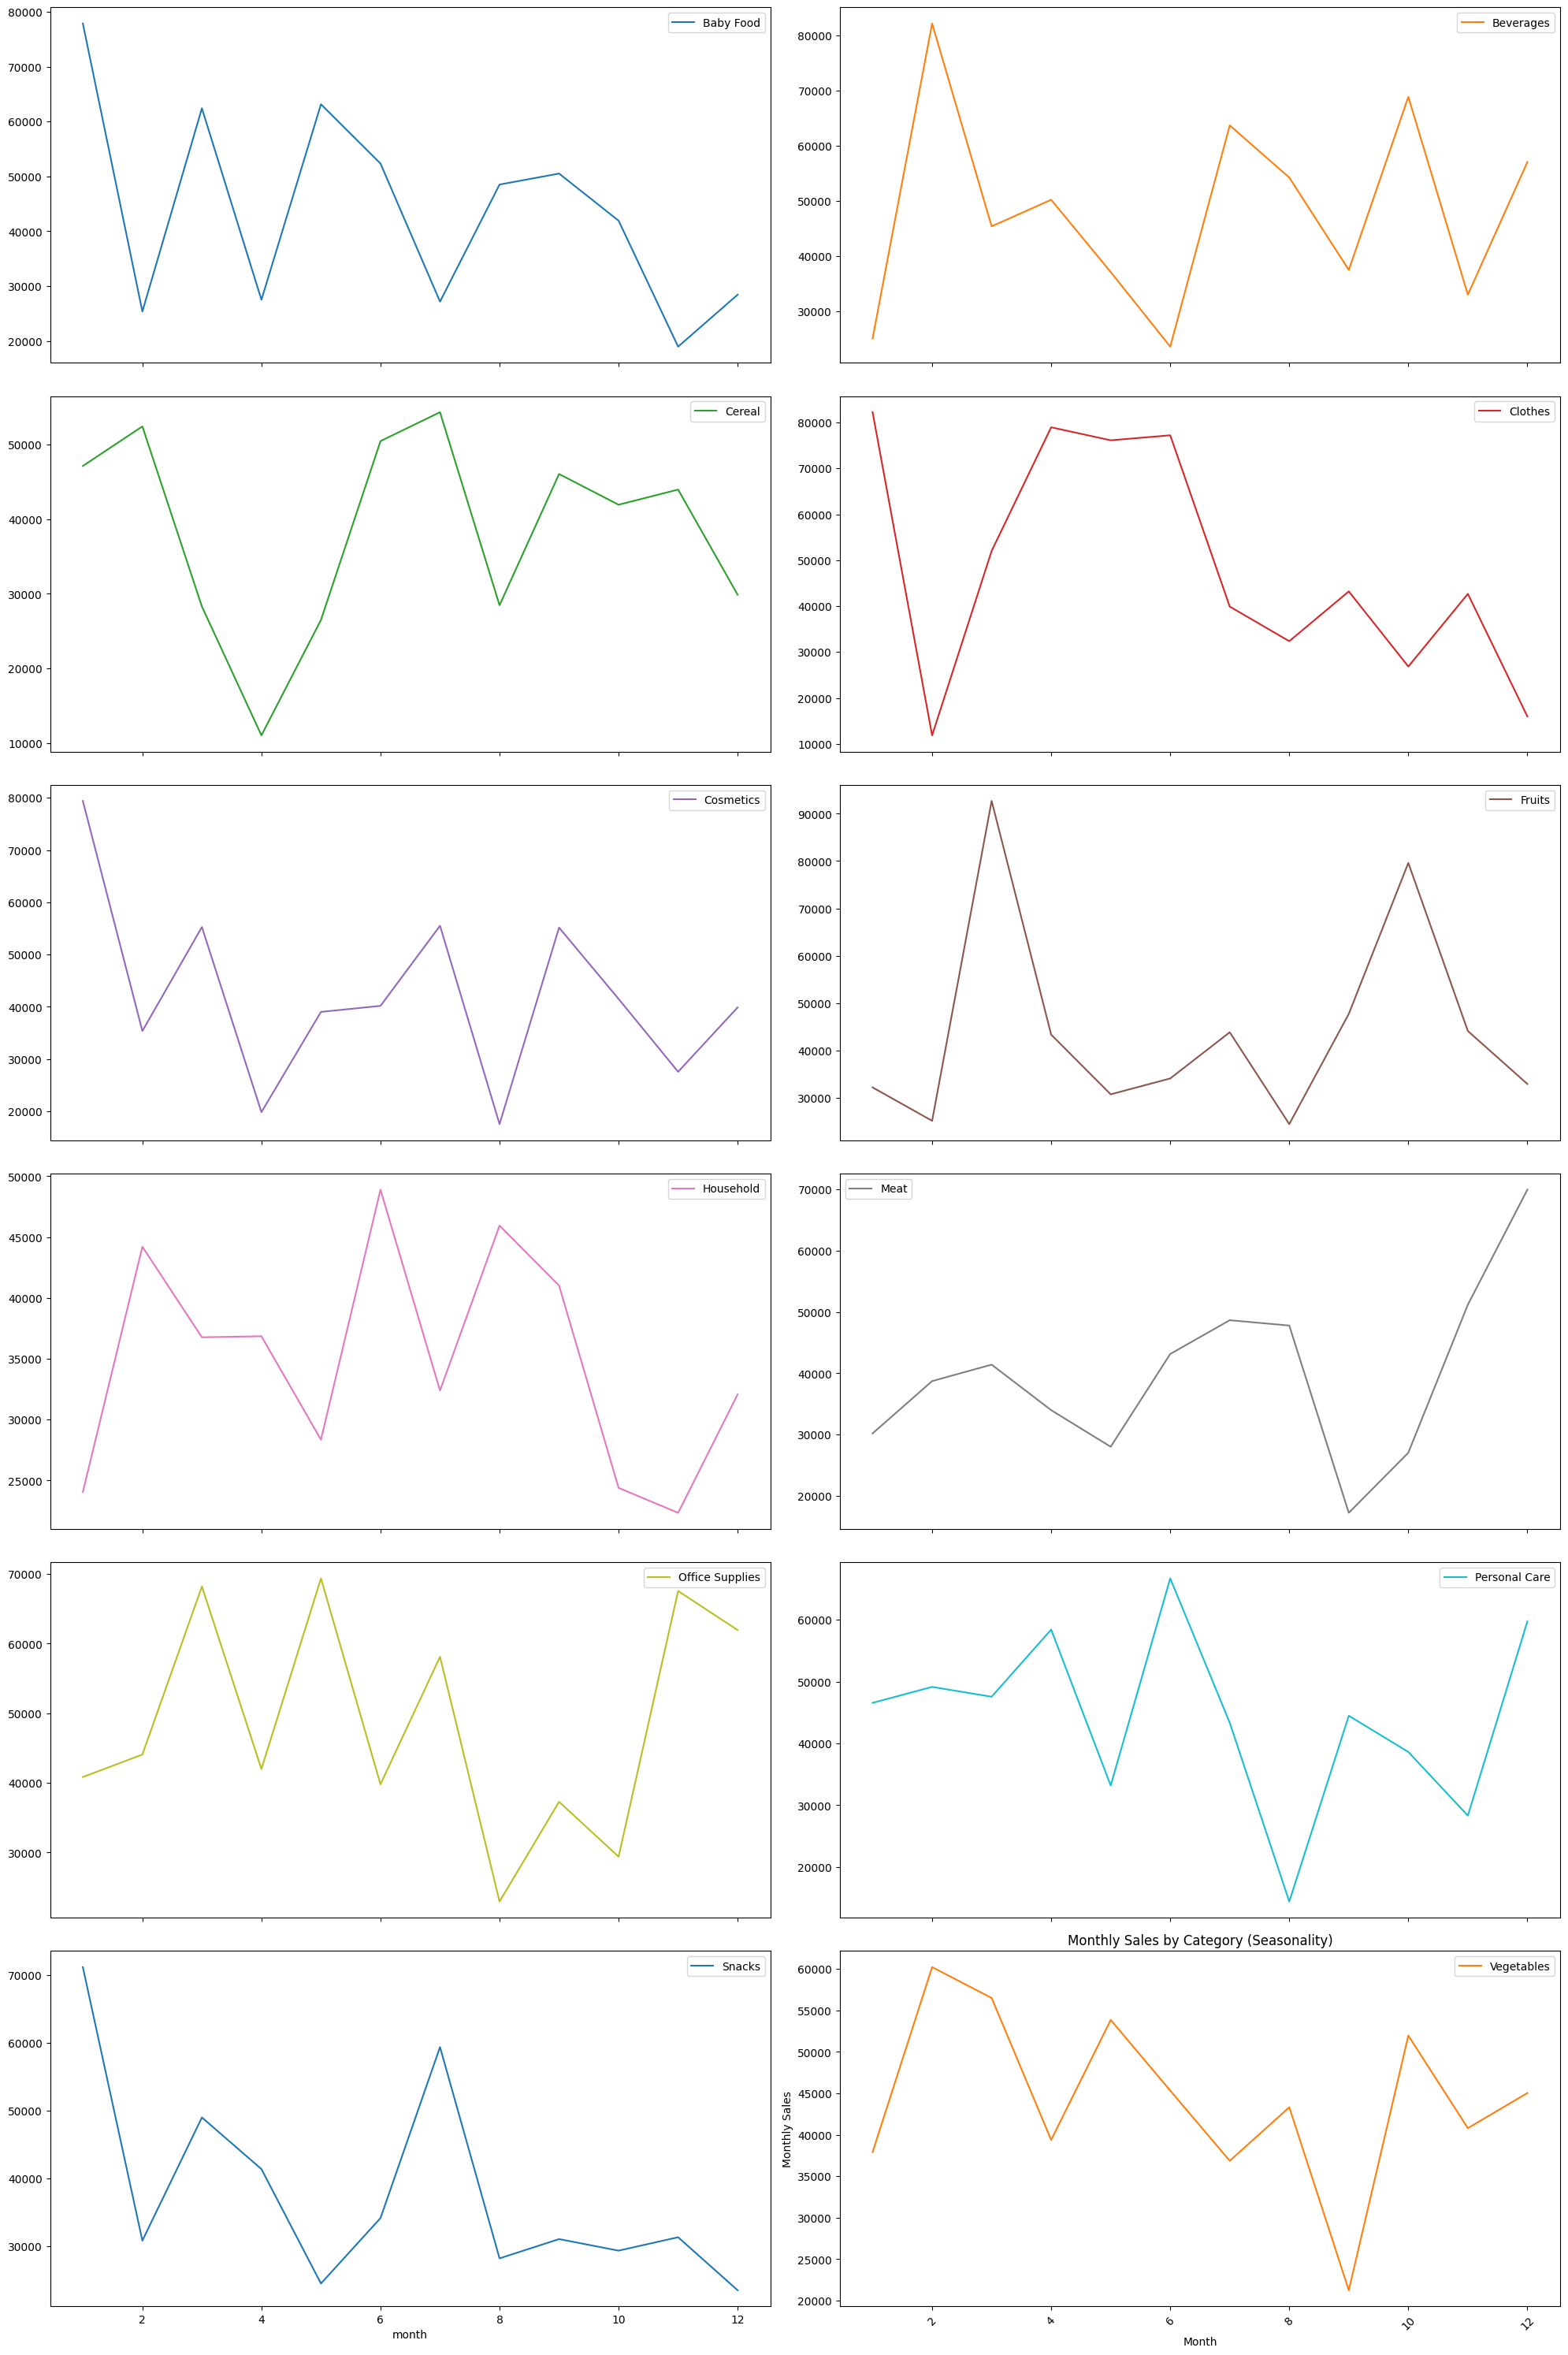

In [ ]:
#Monthly Sales by Category (Seasonality)
df["month"] = df["order_date"].dt.month
gropped_by_category_month = df.groupby(["month", "category"])["units_sold"].sum().unstack("category")
gropped_by_category_month.plot(kind="line", figsize=(20, 30), subplots=True, layout=(6, 2))
plt.title("Monthly Sales by Category (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Clothes shows the clearest seasonal pattern — strong peaks in March (~93K) and sustained high sales through April–July, followed by a sharp drop in August and December. This aligns with spring/summer fashion cycles. Fruits peaks in March and October, suggesting two seasonal demand windows. Beverages spike notably in February and October. Most other categories (Baby Food, Cereal, Office Supplies) remain relatively stable year-round with no clear seasonality, indicating steady demand independent of season.

#Reporting

Executive Summary EN:

This analysis covers sales data across Europe and Asia from 2010 to 2017. Europe dominates all metrics, accounting for ~ 93% of total revenue and profit, while Asia remains a largely untapped market. Cosmetics is the most profitable category by margin, while Office Supplies leads in revenue but with significantly higher costs. Both Online and Offline sales channels perform almost identically, indicating a well-balanced distribution strategy. Shipping times are consistent across categories and regions (~ 25 days on average), with no significant impact on profit. Sales patterns suggest a B2B-driven business model — characterized by large, infrequent orders rather than steady organic growth. Clothes is the only clearly seasonal category (spring/summer peak), while most other categories show stable year-round demand. To accelerate growth, the company should consider expanding into the Asian market, optimizing costs in Office Supplies, and leveraging the high-margin Cosmetics category.